In [1]:
# To Do

# figure out what the step size should be
# figure out why bin size matters so much to lensing ratios
# test if bin size affects MCMC constraints
# update MCMC likelihood
# change the way bins are made? -- logarithmic

## Setup                                                                              

In [2]:
# import tools

# standard library
import glob
import re
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp
import datetime

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import CubicSpline, interp1d
from scipy.optimize import curve_fit
import pandas as pd

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown, HTML
from tabulate import tabulate

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
from cobaya.model import get_model
from cobaya_utilities import fisher
import getdist
import getdist.plots as plots
from getdist import plots, MCSamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples
from getdist.gaussian_mixtures import GaussianND

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [3]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import build_data_vector
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import project_fisher_matrix
from functions_and_classes import get_partial_derivative
from functions_and_classes import sample_fisher_with_uniform_priors
from functions_and_classes import plot_Fisher_from_matrices
from functions_and_classes import load_txt_fisher_matrices
from functions_and_classes import analyze_fisher_matrices
from functions_and_classes import plot_fisher_diagnostics
from functions_and_classes import plot_cobaya_mcmc_results
from functions_and_classes import get_ell_bin_edges

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import FisherForecaster

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [4]:
# cosmologies and priors -- all values from DESI DR2 Chains, DESI+CMB or, if available, DESI+CMB+DESY5

# flat LCDM
# values taken from Planck 2018 TT, TE, EE+lowE
Omega_b = 0.04807
Omega_c = 0.2532
Omega_k = 0
w0 = -1
wa = 0
h = 0.6817
n_s = 0.9693
A_s = 2.122e-9
ln1010A_s = 3.05494413319
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved LCDM
Omega_b = 0.04735
Omega_c = 0.2547
Omega_k = 0.00231
w0 = -1
wa = 0
h = 0.6850
n_s = 0.9649
A_s = 2.115e-9
ln1010A_s = 3.0516399054
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
curved_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# flat wCDM
Omega_b = 0.04929
Omega_c = 0.2591
Omega_k = 0
w0 = -0.9706
wa = 0
h = 0.6734
n_s = 0.9699
A_s = 2.127e-9
ln1010A_s = 3.05729762921
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_wCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})


# flat w0wa
Omega_b = 0.04991
Omega_c = 0.2676
Omega_k = 0
w0 = -0.7521
wa = -0.8611
h = 0.6674
n_s = 0.9654
A_s = 2.094e-9
ln1010A_s = 3.04166120544
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved w0wa
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
curved_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# define prior
# all priors taken from Planck unless otherwise stated (https://arxiv.org/pdf/1303.5076)
uniform_prior = {
    'Omega_c': (0.1, 0.9), # not Planck prior given, prior self chosen
    'wa': (-3, 3),         # wider than Planck prior by 1 in each direction
    'w0': (-3, -0.3),
    'A_s': (1.48797e-9, 5.45981e-9),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221),
    'n_s': (0.9, 1.1),
    'Omega_k': (-0.3, 0.3),
    'm_nu': (0, 5)
}

## Data and Noise

In [5]:
# DESI DES sky overlap: https://watermark02.silverchair.com/stad2221.pdf?token=AQECAHi208BE49Ooan9kkhW_Ercy7Dm3ZL_9Cf3qfKAc485ysgAAA1UwggNRBgkqhkiG9w0BBwagggNCMIIDPgIBADCCAzcGCSqGSIb3DQEHATAeBglghkgBZQMEAS4wEQQMPF_1Rf3PlLw4g5VBAgEQgIIDCIlykzq-IzVjb7Q-kkK-E_5umppOPSrMHOM4UcfgCovcPTCkOTtlNtDEuRTFA8zh7iBGNGsDnd-8gGRpt2fMeYXMDfYdJol0EmAVU0jzC3QS09cUU7bsCWObaMC30q1RllRRoW2tDw7GSidmi6o3q16CC17S3E0jNNYCsN4V1_glxcQLPsOMlNPPvndES-6O6fcMLjmBkTVj5Lqxhp46NfXfdxchfyI0u2lk7KpnQr8MQ7TNZszs8sIL9ksFU-OatEjM9dTdQYZeatWHf8i2By5iBsjDC3kcJgunHdU486xBXXUNLxwte63Ri_ZH5L0Nc5wNxgVP4PueqeUZiVIE_Ws-V_QlzbzWRH5vQ_AczOlvpZCSBNyPdxQ0i0aSXEssjBTePJbpJ744tQgyw9rPheWDeEC-RzSx9thKoGpWl_39VNZkGlcO5WEA-u8S_dzA9B7b55qQnwpHHNX8NS_7zU8s17pbPJfnz7CoTVteiRR9kDfR3IthFsL92-mHtdzDb810c8T3JImSFRGEiUDaMNWjqgcIPWT38wjMZiR_p95oQ897WCLJmD88Ychm-PjGxtNSNU70f9495aOJ4ObOUvEi8gn_ZS6yosWd1bxdHkqgn1KTXY4dii7IuKHmnffcLiAVOytkEe0RuOdLmSsaKfX8HshbaKKrpsmXPcWar3anMykqxkPKvqQxCUVo9wDJq3SDd6evAfr0nBGBZo1bHepZ43VTJzi-2KLhHG2teDw_8yFLOU0lHDgJEYoTfpDvtLHhAklEUd5V4XmjIwN4KcDNt2CJoun9y_zmH-8pdP4Oc5h_XYcTBuvNa7lKYbh2js_SMwANW1cjrv2LeS7eqoLljb1XqsrgxowX61urarvsn2NX-xy2ctqiH0Wjvl3IS88_zzJ_kEdd46dztq6PXNWdpWeImvc_PD2G46eUMQUhOa69a2v1kL_BpCl4WUBQRifU7x3O7SSTyfyOIislu2aDkc-xnAwvdBYL2SFR2kKsXQHC5eELAUm5iVu1_ui6JBTtjeGDj7Jv

In [6]:
# BGS and LRG data

# make arrays
data_dir = "data/dNdz"

bgs1 = np.loadtxt(os.path.join(data_dir, "BGSz1_dNdz.txt"))
bgs2 = np.loadtxt(os.path.join(data_dir, "BGSz2_dNdz.txt"))
BGS_distributions = np.column_stack((bgs1[:, 0], bgs1[:, 1], bgs2[:, 1]))
BGS_distributions_bin1 = np.column_stack((bgs1[:, 0], bgs1[:, 1]))

lrg1 = np.loadtxt(os.path.join(data_dir, "LRGz1_dNdz.txt"))
lrg2 = np.loadtxt(os.path.join(data_dir, "LRGz2_dNdz.txt"))
lrg3 = np.loadtxt(os.path.join(data_dir, "LRGz3_dNdz.txt"))
lrg4 = np.loadtxt(os.path.join(data_dir, "LRGz4_dNdz.txt"))
LRG_distributions = np.column_stack((lrg1[:, 0], lrg1[:, 1], lrg2[:, 1], lrg3[:, 1], lrg4[:, 1]))
LRG_distributions_bin1 = np.column_stack((lrg1[:, 0], lrg1[:, 1]))

# normalize
z_bgs = BGS_distributions[:, 0]

for i in range(1, BGS_distributions.shape[1]):
    area = np.trapezoid(BGS_distributions[:, i], x=z_bgs)
    if area > 0:
        BGS_distributions[:, i] /= area

z_lrg = LRG_distributions[:, 0]

for i in range(1, LRG_distributions.shape[1]):
    area = np.trapezoid(LRG_distributions[:, i], x=z_lrg)
    if area > 0:
        LRG_distributions[:, i] /= area

In [7]:
# BGS and LRG bins on a unified grid

# define a common grid
z_min = min(BGS_distributions[:, 0].min(), LRG_distributions[:, 0].min())
z_max = max(BGS_distributions[:, 0].max(), LRG_distributions[:, 0].max())
z_master = np.arange(z_min, z_max + 0.001, 0.01)

# initialize
BGS_LRG_distributions = np.zeros((len(z_master), 7))
BGS_LRG_distributions[:, 0] = z_master

# interpolate
z_bgs = BGS_distributions[:, 0]
for i in range(1, 3):  # Columns 1, 2
    BGS_LRG_distributions[:, i] = np.interp(
        z_master, z_bgs, BGS_distributions[:, i], left=0.0, right=0.0
    )

z_lrg = LRG_distributions[:, 0]
for i in range(1, 5):  # Columns 1, 2, 3, 4
    BGS_LRG_distributions[:, i + 2] = np.interp(
        z_master, z_lrg, LRG_distributions[:, i], left=0.0, right=0.0
    )

# renormalize
for col in range(1, 7):
    area = np.trapezoid(BGS_LRG_distributions[:, col], x=z_master)
    if area > 0:
        BGS_LRG_distributions[:, col] /= area


# save
data_dir = "data"
np.save(os.path.join(data_dir, "BGS_distributions_bin1.npy"), BGS_distributions_bin1)
np.save(os.path.join(data_dir, "BGS_distributions.npy"), BGS_distributions)
np.save(os.path.join(data_dir, "LRG_distributions_bin1.npy"), LRG_distributions_bin1)
np.save(os.path.join(data_dir, "LRG_distributions.npy"), LRG_distributions)
np.save(os.path.join(data_dir, "BGS_LRG_distributions.npy"), BGS_LRG_distributions)

In [8]:
# HSC and DES source data

# HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

# DES Source Data

DES_source_data = np.loadtxt("data/des_nz_gamma.txt")
DES_source_data = DES_source_data[7:]  # removes the first 7 values (headers)
DES_source_data = DES_source_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DES_source_z    = DES_source_data[:, 0]
DES_source_nz_a = DES_source_data[:, 1]
DES_source_nz_b = DES_source_data[:, 2]
DES_source_nz_c = DES_source_data[:, 3]
DES_source_nz_d = DES_source_data[:, 4]

DES_source_data = np.column_stack((DES_source_z, DES_source_nz_a, DES_source_nz_b, DES_source_nz_c, DES_source_nz_d))

# DES normalization
area_a = np.trapezoid(DES_source_nz_a, x=DES_source_z)
area_b = np.trapezoid(DES_source_nz_b, x=DES_source_z)
area_c = np.trapezoid(DES_source_nz_c, x=DES_source_z)
area_d = np.trapezoid(DES_source_nz_d, x=DES_source_z)

DES_source_nz_a_norm = DES_source_nz_a / area_a
DES_source_nz_b_norm = DES_source_nz_b / area_b
DES_source_nz_c_norm = DES_source_nz_c / area_c
DES_source_nz_d_norm = DES_source_nz_d / area_d

DES_source_data = np.column_stack((DES_source_z, DES_source_nz_a_norm, DES_source_nz_b_norm, DES_source_nz_c_norm, DES_source_nz_d_norm))
DES_source_data_bin1 = np.column_stack((DES_source_z, DES_source_nz_a_norm))
des_bins_norm = [DES_source_nz_a_norm, DES_source_nz_b_norm, DES_source_nz_c_norm, DES_source_nz_d_norm]

# save
data_dir = "data"
np.save(os.path.join(data_dir, "DES_source_data.npy"), DES_source_data)
np.save(os.path.join(data_dir, "DES_source_data_bin1.npy"), DES_source_data_bin1)
np.save(os.path.join(data_dir, "HSC_source_data.npy"), HSC_dist_0_3)

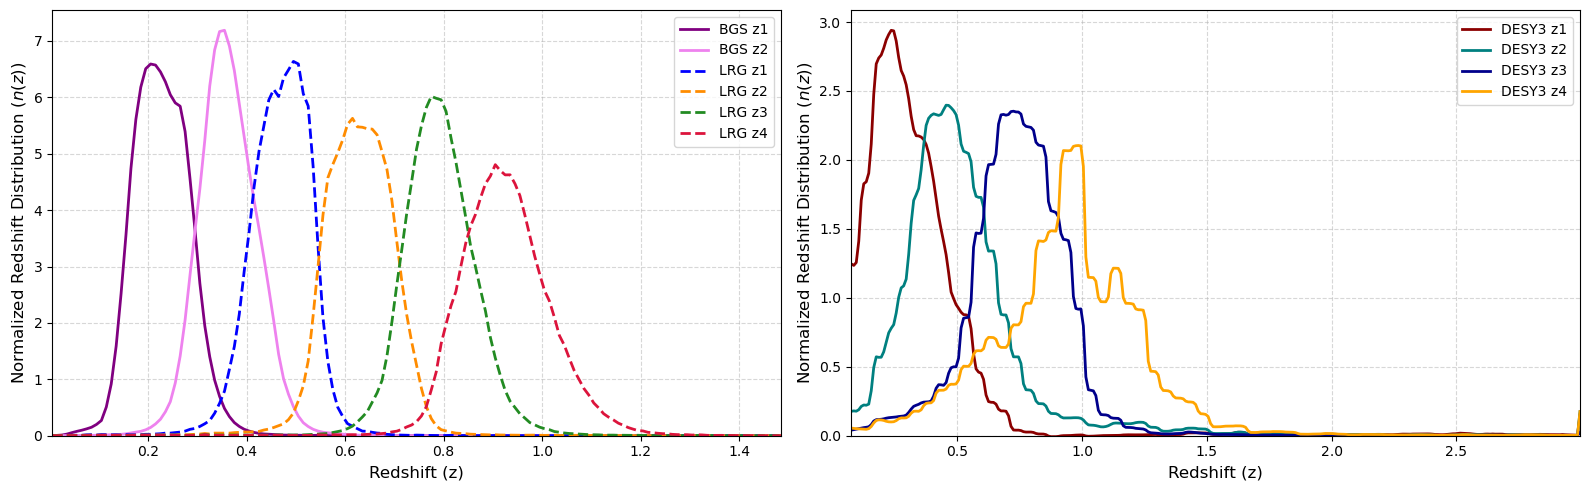

In [9]:
# plot all bins together

des_colors = ["darkred", "teal", "darkblue", "orange"]

# --- Figure setup: 1 row, 2 columns ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# Left Subplot: BGS & LRG Bins
z_master = BGS_LRG_distributions[:, 0]

ax1.plot(
    z_master,
    BGS_LRG_distributions[:, 1],
    label="BGS z1",
    color="purple",
    lw=2,
)
ax1.plot(
    z_master,
    BGS_LRG_distributions[:, 2],
    label="BGS z2",
    color="violet",
    lw=2,
)

lrg_colors = ["blue", "darkorange", "forestgreen", "crimson"]
for i in range(1, 5):
    ax1.plot(
        z_master,
        BGS_LRG_distributions[:, i + 2],
        label=f"LRG z{i}",
        color=lrg_colors[i - 1],
        lw=2,
        linestyle="--",
    )

ax1.set_xlabel("Redshift (z)", fontsize=12)
ax1.set_ylabel("Normalized Redshift Distribution ($n(z)$)", fontsize=12)
ax1.set_xlim(z_master.min(), z_master.max())
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(fontsize=10, loc="upper right", frameon=True)

# Right Subplot: DES Source Bins
for i, (nz_norm, color) in enumerate(zip(des_bins_norm, des_colors), start=1):
    ax2.plot(
        DES_source_z,
        nz_norm,
        label=f"DESY3 z{i}",
        color=color,
        lw=2,
    )

ax2.set_xlabel("Redshift (z)", fontsize=12)
ax2.set_ylabel("Normalized Redshift Distribution ($n(z)$)", fontsize=12)
ax2.set_xlim(DES_source_z.min(), DES_source_z.max())
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(fontsize=10, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

[1.02326265e-09]


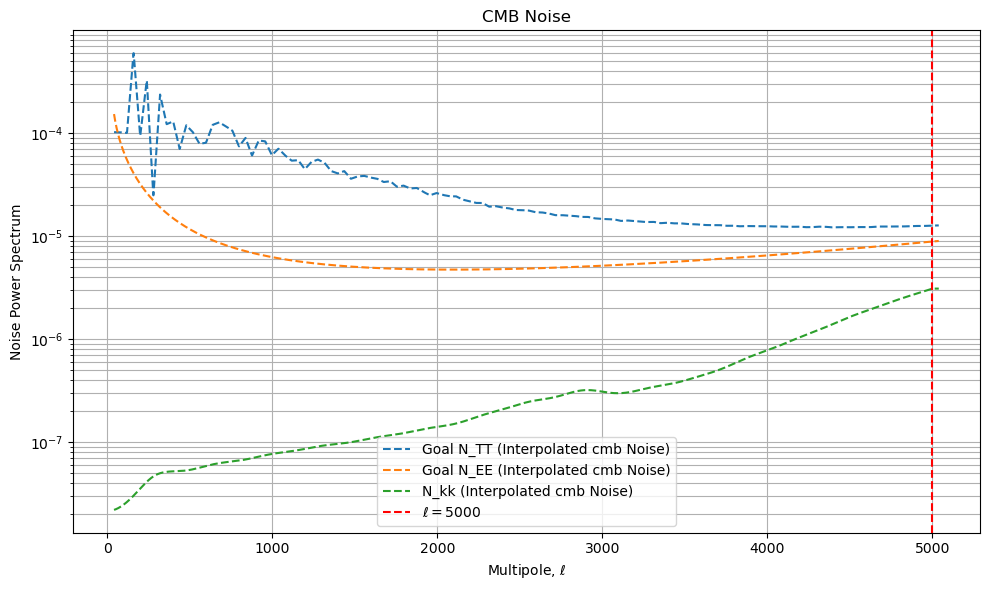

In [10]:
# build noise magnification
# BGS shot noise ref: 
# LRG shot noise ref: https://arxiv.org/pdf/2407.04607
# DES noise ref: https://arxiv.org/html/2511.04681v2
# HSC noise ref: https://arxiv.org/pdf/2507.01386
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
LRG_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree
LRG_n_bar_steradian = LRG_n_bar_deg2 * (180.0 / np.pi)**2
HSC_n_bar_arcmin2 = np.array([3.77, 5.07, 4.00, 2.12])
HSC_n_bar_deg2 = HSC_n_bar_arcmin2 * (60 ** 2)
HSC_n_bar_steradian = HSC_n_bar_deg2 * (180.0 / np.pi)**2
DES_n_bar_arcmin2 = np.array([5.59, 5.59, 5.59, 5.59])
DES_n_bar_deg2 = DES_n_bar_arcmin2 * (60 ** 2)
DES_n_bar_steradian = DES_n_bar_deg2 * (180.0 / np.pi)**2
BGS_shot_noise = [4.63e-7, 9.18e-7]
BGS_shot_noise_bin1 = [4.63e-7]
LRG_shot_noise = [4.07e-6, 2.25e-6, 2.05e-6, 2.25e-6]
LRG_shot_noise_bin1 = [4.07e-6]
BGS_LRG_shot_noise = [4.63e-7, 9.18e-7, 4.07e-6, 2.25e-6, 2.05e-6, 2.25e-6]

HSC_shape_noise = np.zeros_like(HSC_n_bar_steradian)
for i in range(len(HSC_shape_noise)):
    HSC_shape_noise[i] = sigma ** 2 / HSC_n_bar_steradian[i]

DES_shape_noise = np.zeros_like(DES_n_bar_steradian)
for i in range(len(DES_shape_noise)):
    DES_shape_noise[i] = sigma ** 2 / DES_n_bar_steradian[i]
DES_shape_noise_bin1 = np.array([DES_shape_noise[0]])
print(DES_shape_noise_bin1)

# cmb noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_goal_T_noise_data = np.loadtxt("data/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt")
SO_goal_T_noise_ells = SO_goal_T_noise_data[:, 0]
SO_goal_N_TT = SO_goal_T_noise_data[:, 1]
SO_goal_E_noise_data = np.loadtxt("data/SO_LAT_Nell_P_goal_fsky0p4_ILC_CMB_E.txt")
SO_goal_E_noise_ells = SO_goal_E_noise_data[:, 0]
SO_goal_N_EE = SO_goal_E_noise_data[:, 1]
SO_kk_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
SO_kk_noise_ells = SO_kk_noise_data[:, 0]
SO_N_kk = SO_kk_noise_data[:, 7]
ells_for_noise_interp = np.arange(40, 5000 + 40)
min1000_ells_for_noise_interp = np.arange(1000, 4000 + 1000)
min2000_ells_for_noise_interp = np.arange(2000, 3000 + 2000)
max2040_ells_for_noise_interp = np.arange(40, 2040)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_goal_N_TT_func = interp1d(SO_goal_T_noise_ells, SO_goal_N_TT, bounds_error=False, fill_value=(SO_goal_N_TT[0], SO_goal_N_TT[-1]))
SO_goal_cmb_noise_TT = interpolated_goal_N_TT_func(ells_for_noise_interp)
interpolated_goal_N_EE_func = interp1d(SO_goal_E_noise_ells, SO_goal_N_EE, bounds_error=False, fill_value=(SO_goal_N_EE[0], SO_goal_N_EE[-1]))
SO_goal_cmb_noise_EE = interpolated_goal_N_EE_func(ells_for_noise_interp)
interpolated_N_kk_func = interp1d(SO_kk_noise_ells, SO_N_kk, bounds_error=False, fill_value=(SO_N_kk[0], SO_N_kk[-1]))
SO_cmb_noise_kk = interpolated_N_kk_func(ells_for_noise_interp)
min1000_SO_cmb_noise_kk = interpolated_N_kk_func(min1000_ells_for_noise_interp)
min2000_SO_cmb_noise_kk = interpolated_N_kk_func(min2000_ells_for_noise_interp)
max2040_SO_cmb_noise_kk = interpolated_N_kk_func(max2040_ells_for_noise_interp)

# plot cmb noise to see what it looks like
plt.figure(figsize=(10, 6))
plt.semilogy(ells_for_noise_interp, SO_goal_cmb_noise_TT, label='Goal N_TT (Interpolated cmb Noise)', linestyle='--')
plt.semilogy(ells_for_noise_interp, SO_goal_cmb_noise_EE, label='Goal N_EE (Interpolated cmb Noise)', linestyle='--')
plt.semilogy(ells_for_noise_interp, SO_cmb_noise_kk, label='N_kk (Interpolated cmb Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum')
plt.title('CMB Noise')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

# save
data_dir = "data"
np.save(os.path.join(data_dir, "BGS_shot_noise.npy"), BGS_shot_noise)
np.save(os.path.join(data_dir, "BGS_shot_noise_bin1.npy"), BGS_shot_noise_bin1)
np.save(os.path.join(data_dir, "LRG_shot_noise.npy"), LRG_shot_noise)
np.save(os.path.join(data_dir, "LRG_shot_noise_bin1.npy"), LRG_shot_noise_bin1)
np.save(os.path.join(data_dir, "BGS_LRG_shot_noise.npy"), BGS_LRG_shot_noise)
np.save(os.path.join(data_dir, "HSC_shape_noise.npy"), HSC_shape_noise)
np.save(os.path.join(data_dir, "DES_shape_noise.npy"), DES_shape_noise)
np.save(os.path.join(data_dir, "DES_shape_noise_bin1.npy"), DES_shape_noise_bin1)
np.save(os.path.join(data_dir, "SO_goal_cmb_noise_TT.npy"), SO_goal_cmb_noise_TT)
np.save(os.path.join(data_dir, "SO_goal_cmb_noise_EE.npy"), SO_goal_cmb_noise_EE)
np.save(os.path.join(data_dir, "SO_cmb_noise_kk.npy"), SO_cmb_noise_kk)

# Fisher

## Curved w0waCDM

In [11]:
recommended_h = {
    "Omega_c": 1.420e-03,
    "A_s": 3.954e-13,
    "h": 2.577e-03,
    "w0": 3.445e-03,
    "wa": 5.428e-04,
    "n_s": 2.133e-04,
    "Omega_b": 4.594e-05,
    "Omega_k": 4.080e-06,
}

In [13]:
ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = 3.0714e-02  (+0.40σ)  <-- >0.3σ shift
  ΔA_s = -2.9361e-09  (-0.41σ)  <-- >0.3σ shift
  Δh = 3.6359e-01  (+0.36σ)  <-- >0.3σ shift
  Δw0 = 2.3412e-02  (+0.04σ)
  Δwa = -1.4905e-02  (-0.01σ)
  Δn_s = -4.4895e-01  (-0.48σ)  <-- >0.3σ shift
  ΔOmega_b = -4.2287e-02  (-0.29σ)
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = 4.7566e-02  (+0.61σ)  <-- >0.3σ shift
  ΔA_s = 1.6557e-09  (+0.23σ)
  Δh = -3.8655e-01  (-0.39σ)  <-- >0.3σ shift
  Δw0 = -4.7785e-02  (-0.07σ)
  Δwa = 4.4864e-01  (+0.34σ)  <-- >0.3σ shift
  Δn_s = 2.0381e-01  (+0.22σ)
  ΔOmega_b = -1.9437e-02  (-0.13σ)


In [14]:
ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['CC', 'CL', 'LL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = 4.2338e-02  (+0.13σ)
  ΔA_s = -9.0141e-10  (-0.69σ)  <-- >0.3σ shift
  Δh = 9.7519e-02  (+0.22σ)
  Δw0 = 1.4001e+00  (+0.22σ)
  Δwa = -4.9859e+00  (-0.24σ)
  Δn_s = -1.0123e-01  (-0.81σ)  <-- >0.3σ shift
  ΔOmega_b = 2.1136e-02  (+0.29σ)
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = -2.5682e-02  (-0.08σ)
  ΔA_s = 1.0817e-09  (+0.83σ)  <-- >0.3σ shift
  Δh = -1.4701e-01  (-0.33σ)  <-- >0.3σ shift
  Δw0 = -1.1624e+00  (-0.18σ)
  Δwa = 4.7492e+00  (+0.23σ)
  Δn_s = 1.1645e-01  (+0.93σ)  <-- >0.3σ shift
  ΔOmega_b = -2.2748e-02  (-0.31σ)  <-- >0.3σ shift


In [15]:
ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['GL', 'CG', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = -5.5056e-02  (-1.42σ)  <-- >0.3σ shift
  ΔA_s = -7.5122e-12  (-1.65σ)  <-- >0.3σ shift
  Δh = 6.3018e-02  (+1.33σ)  <-- >0.3σ shift
  Δw0 = -4.2497e-01  (-1.42σ)  <-- >0.3σ shift
  Δwa = 9.0007e-01  (+1.23σ)  <-- >0.3σ shift
  Δn_s = 4.1944e-03  (+1.61σ)  <-- >0.3σ shift
  ΔOmega_b = -9.2293e-03  (-1.31σ)  <-- >0.3σ shift
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = 9.1575e-02  (+2.36σ)  <-- >0.3σ shift
  ΔA_s = 7.8821e-12  (+1.73σ)  <-- >0.3σ shift
  Δh = -1.0797e-01  (-2.28σ)  <-- >0.3σ shift
  Δw0 = 5.5758e-01  (+1.87σ)  <-- >0.3σ shift
  Δwa = -7.8713e-01  (-1.08σ)  <-- >0.3σ shift
  Δn_s = -4.8031e-03  (-1.84σ)  <-- >0.3σ shift
  ΔOmega_b = 1.5921e-02  (+2.27σ)  <-- >0.3σ shift


In [16]:
ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = 0.0000e+00  (+0.00σ)
  ΔA_s = 0.0000e+00  (+0.00σ)
  Δh = 0.0000e+00  (+0.00σ)
  Δw0 = 0.0000e+00  (+0.00σ)
  Δwa = 0.0000e+00  (+0.00σ)
  Δn_s = 0.0000e+00  (+0.00σ)
  ΔOmega_b = 0.0000e+00  (+0.00σ)
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = 0.0000e+00  (+0.00σ)
  ΔA_s = 0.0000e+00  (+0.00σ)
  Δh = 0.0000e+00  (+0.00σ)
  Δw0 = 0.0000e+00  (+0.00σ)
  Δwa = 0.0000e+00  (+0.00σ)
  Δn_s = 0.0000e+00  (+0.00σ)
  ΔOmega_b = 0.0000e+00  (+0.00σ)


In [17]:
ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['LL' 'CC', 'CL', 'CG', 'GL', 'CG', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = -2.4076e-02  (-0.75σ)  <-- >0.3σ shift
  ΔA_s = -5.4299e-12  (-1.26σ)  <-- >0.3σ shift
  Δh = 2.5962e-02  (+0.66σ)  <-- >0.3σ shift
  Δw0 = -2.8958e-01  (-1.02σ)  <-- >0.3σ shift
  Δwa = 8.6618e-01  (+1.22σ)  <-- >0.3σ shift
  Δn_s = 2.7978e-03  (+1.16σ)  <-- >0.3σ shift
  ΔOmega_b = -3.7374e-03  (-0.64σ)  <-- >0.3σ shift
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = 5.1410e-02  (+1.61σ)  <-- >0.3σ shift
  ΔA_s = 5.0182e-12  (+1.17σ)  <-- >0.3σ shift
  Δh = -6.0034e-02  (-1.53σ)  <-- >0.3σ shift
  Δw0 = 3.8736e-01  (+1.36σ)  <-- >0.3σ shift
  Δwa = -7.6059e-01  (-1.07σ)  <-- >0.3σ shift
  Δn_s = -2.9113e-03  (-1.21σ)  <-- >0.3σ shift
  ΔOmega_b = 8.8195e-03  (+1.52σ)  <-- >0.3σ shift


In [18]:
ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['LL', 'CC', 'CL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = -3.4978e-02  (-1.19σ)  <-- >0.3σ shift
  ΔA_s = -1.4565e-12  (-0.33σ)  <-- >0.3σ shift
  Δh = 4.2197e-02  (+1.12σ)  <-- >0.3σ shift
  Δw0 = -2.0515e-01  (-0.48σ)  <-- >0.3σ shift
  Δwa = 2.3547e-01  (+0.19σ)
  Δn_s = 1.0767e-03  (+0.48σ)  <-- >0.3σ shift
  ΔOmega_b = -6.2463e-03  (-1.12σ)  <-- >0.3σ shift
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = 2.6234e-02  (+0.89σ)  <-- >0.3σ shift
  ΔA_s = 9.3716e-13  (+0.22σ)
  Δh = -3.1709e-02  (-0.84σ)  <-- >0.3σ shift
  Δw0 = 1.5559e-01  (+0.36σ)  <-- >0.3σ shift
  Δwa = -1.8141e-01  (-0.15σ)
  Δn_s = -7.2312e-04  (-0.32σ)  <-- >0.3σ shift
  ΔOmega_b = 4.6935e-03  (+0.84σ)  <-- >0.3σ shift


# MCMC

## Syntax

In [ ]:
cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/flat_LCDM_LR_Photo_BGS_DES_bin1_bs50_likelihood.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

In [ ]:
CHAIN_DEST="chains/flat_LCDM_LR_Photo_BGS_DES_bin1_bs50_likelihood"
mkdir -p $CHAIN_DEST

for i in {0..3}; do
    cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt $CHAIN_DEST/chain_task_${i}.txt
    ln -sf chain_task_${i}.txt $CHAIN_DEST/cosmo_run.${i}.txt
done

# Copy the paramnames file so your plotting code works immediately
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/chain_task.paramnames
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/cosmo_run.paramnames

## Covariances and MCMCs

In [14]:
# calculate and save flat LCDM fiducial data vector and covariance matrix for single bin w/lensing ratios primaries

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

# extract other parameters directly, or hardcode them if they are constant for this generation step
l_min = 40
n_ell = 5000
binsize = 100
magnification_bias_lenses = 0.8

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        flat_LCDM_cosmology,
        BGS_distributions_bin1,
        DES_source_data_bin1,
        f_sky_c = 0.4,
        f_sky_g = 0.4,
        f_sky_l = 0.1,
        f_sky_c_g = 0.295,
        f_sky_c_l = 0.0306,
        f_sky_g_l = 0.0306,
        f_sky_c_g_l = 0.0306,
        l_min=l_min,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=BGS_shot_noise_bin1,
        shape_noise_source=DES_shape_noise_bin1,
        cmb_noise_kk=SO_cmb_noise_kk,
        cmb_noise_TT=SO_goal_cmb_noise_TT,
        cmb_noise_EE=SO_goal_cmb_noise_EE,
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=['CG', 'GL'],
        linear_emulator=None,
        boost_emulator=None,
        cmb_primaries = True,
        z_max = 6,
        n_chi = 1024
    )

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# extract and flatten the fiducial data vector
observed_data_vector = build_data_vector(forecast_map = f_map, spectra_dict = fiducial_spectra_dict, n_ell = n_ell, binsize = binsize)

# Save to files
data_vector_filename = 'cobaya_data/flat_LCDM_LR_Photo_BGS_DES_bin1_data_vector_binsize_100.npy'
covariance_filename = 'cobaya_data/flat_LCDM_LR_Photo_BGS_DES_bin1_covariance_matrix_binsize_100.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)